## Exploratory Data Analysis

### Data Loading

Processed datasets containing crime records, population figures, and socioeconomic indicators are loaded for analysis.

In [1]:
import pandas as pd
import os


crime_data = pd.read_csv("../data/processed/crime_data.csv")
population_by_province = pd.read_csv("../data/processed/population_by_province.csv")
population_indicators = pd.read_csv("../data/processed/population_indicators.csv")
socioeconomic_indicators = pd.read_csv("../data/processed/socioeconomic_data.csv")

#### Crime Data Overview

In [2]:
display(crime_data.head(3))
display(crime_data.tail(3))
display(crime_data["Crime_category"].unique())

,Crime_category,Crime_subcategory,Province,Canton,Year,Month
0,Vehicle Theft,Negligence / Left Unattended,San José,Acosta,2015,5
1,Vehicle Theft,Negligence / Left Unattended,Guanacaste,Abangares,2015,7
2,Vehicle Theft,Negligence / Left Unattended,San José,San Jose,2015,4


,Crime_category,Crime_subcategory,Province,Canton,Year,Month
562622,Vehicle Breaking and Entering,Vehicle Breaking and Entering,Limón,Limon,2025,12
562623,Vehicle Breaking and Entering,Vehicle Breaking and Entering,San José,San Jose,2025,12
562624,Vehicle Breaking and Entering,Vehicle Breaking and Entering,San José,San Jose,2025,12


<StringArray>
[                'Vehicle Theft', 'Vehicle Breaking and Entering',
                       'Assault',                      'Homicide',
                         'Theft',                       'Robbery']
Length: 6, dtype: str

This dataset contains crime records from 2015 to 2025, categorized into six distinct types: Assault, Homicide, Robbery, Theft, Vehicle Theft, and Vehicle Breaking and Entering.

#### Population by Province Data Overview

In [3]:
display(population_by_province.head(3))
display(population_by_province.tail(3))

,Province,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Alajuela,977423,990846,1003571,1015703,1026100,1034594,1042259,1050190,1058895,1067200,1075129
1,Cartago,513655,517586,521104,524263,526556,527870,528738,529690,531010,532077,532913
2,Guanacaste,371871,377491,382859,388004,392476,396220,399614,403023,406746,410331,413767


,Province,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
4,Limón,424487,429248,433724,437961,441419,444088,446285,448645,451222,453600,455802
5,Puntarenas,462598,468651,474413,479912,484542,488231,491511,494936,498693,502255,505637
6,San José,1584387,1597858,1610184,1621498,1630307,1636181,1640734,1645551,1651767,1657287,1662138


This dataset provides yearly population estimates for each province, covering the period from 2015 to 2025.

#### Population Indicators Overview

In [4]:
display(population_indicators.head(3))
display(population_indicators.tail(3))

,Province,Year,Annual_Growth,Growth_Rate_per_100,Population_Density
0,Alajuela,2015,"13,909",1.43,99.63
1,Alajuela,2016,"13,423",1.36,100.99
2,Alajuela,2017,"12,725",1.28,102.29


,Province,Year,Annual_Growth,Growth_Rate_per_100,Population_Density
74,San José,2023,"6,216",0.38,332.36
75,San José,2024,"5,520",0.33,333.47
76,San José,2025,"4,850",0.29,334.45


This dataset includes demographic indicators such as population density (calculated using only habitable areas) and the annual population growth rate, measured per 100 inhabitants.

#### Socioeconomic Data Overview

In [5]:
display(socioeconomic_indicators.head(10))

,Indicator Name,Indicator Code,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,"Labor force participation rate, total (% of to...",SL.TLF.CACT.NE.ZS,62.808000,59.687000,59.848000,62.210000,64.263000,60.629000,61.766000,61.491000,56.831000,57.687000,55.935
1,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,8.415000,8.085000,7.729000,9.010000,10.807000,16.432000,15.139000,11.325000,8.325000,6.936000,6.342
2,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,0.801982,-0.017479,1.625907,2.221115,2.096046,0.724911,1.726478,8.274775,0.525194,-0.412853,NaN
3,Gini index,SI.POV.GINI,48.400000,48.700000,48.300000,48.000000,48.200000,49.200000,48.700000,47.200000,46.700000,45.800000,45.500
4,Poverty gap at $3.00 a day (2021 PPP) (%),SI.POV.GAPS,0.900000,0.800000,0.600000,0.900000,0.600000,1.300000,0.700000,0.500000,0.500000,0.400000,0.200
5,Poverty headcount ratio at national poverty li...,SI.POV.NAHC,23.600000,22.900000,22.100000,22.900000,23.900000,30.000000,26.200000,25.500000,24.400000,20.300000,17.100
6,"Lower secondary completion rate, total (% of r...",SE.SEC.CMPT.LO.ZS,54.110489,54.544380,56.412071,66.075569,70.422607,65.387268,67.588173,65.270561,62.284210,61.386978,NaN
7,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GB.ZS,23.373430,23.423201,30.151421,26.086670,32.591579,30.082211,31.166620,21.581961,20.378830,NaN,NaN


The socioeconomic dataset provides various macroeconomic indicators. Note that some indicators have limited data availability within the 2015–2025 timeline. For instance, government education expenditure data is only available up to 2023, while lower secondary completion rates and inflation extend only to 2024.

#### Data cleaning  

#### Removing Non-Analyzed Crime Provinces

In [6]:
crime_data["Province"].unique()

<StringArray>
[   'San José',  'Guanacaste',    'Alajuela',     'Heredia',       'Limón',
  'Puntarenas',     'Cartago', 'Desconocido',      ' Islas', ' Ciudad Del']
Length: 10, dtype: str

Crime records with unknown locations or those outside Costa Rica are being excluded from the analysis to focus on relevant geographical areas.

In [7]:
provincias = [
    "San José",
    "Alajuela",
    "Cartago",
    "Heredia",
    "Guanacaste",
    "Puntarenas",
    "Limón"
]

crime_data = crime_data[
    crime_data["Province"].isin(provincias)
]
crime_data["Province"].unique()

<StringArray>
[  'San José', 'Guanacaste',   'Alajuela',    'Heredia',      'Limón',
 'Puntarenas',    'Cartago']
Length: 7, dtype: str

Only the seven provinces of Costa Rica are included in this analysis, as the project aims to examine the socioeconomic and demographic factors influencing crime specifically within these regions.

In [8]:
crime_data["Canton"].unique()

<StringArray>
[             'Acosta',           'Abangares',            'San Jose',
          'Goicoechea',            'Alajuela',            'Puriscal',
         'Desconocido',       'Montes De Oca',               'Barva',
           'Talamanca',          'San Carlos',               'Tibas',
             'Cartago',               'Limon',             'Parrita',
          'Los Chiles',               'Cañas',             'Naranjo',
              'Nicoya',          'Corredores',           'Sarapiqui',
            'Garabito',             'Heredia',              'Pococi',
             'Esparza',              'Grecia',          'Puntarenas',
          'Santa Cruz',       'Santo Domingo',            'Palmares',
             'Liberia',             'La Cruz',           'Coto Brus',
                 'Osa',             'Tilaran',           'Nandayure',
             'Orotina',             'Golfito',           'San Ramon',
            'Carrillo',           'Siquirres', 'Vasquez De Coronado',
      

In [9]:
crime_data = crime_data[crime_data["Canton"] != "Desconocido"]
crime_data["Canton"].unique()

<StringArray>
[             'Acosta',           'Abangares',            'San Jose',
          'Goicoechea',            'Alajuela',            'Puriscal',
       'Montes De Oca',               'Barva',           'Talamanca',
          'San Carlos',               'Tibas',             'Cartago',
               'Limon',             'Parrita',          'Los Chiles',
               'Cañas',             'Naranjo',              'Nicoya',
          'Corredores',           'Sarapiqui',            'Garabito',
             'Heredia',              'Pococi',             'Esparza',
              'Grecia',          'Puntarenas',          'Santa Cruz',
       'Santo Domingo',            'Palmares',             'Liberia',
             'La Cruz',           'Coto Brus',                 'Osa',
             'Tilaran',           'Nandayure',             'Orotina',
             'Golfito',           'San Ramon',            'Carrillo',
           'Siquirres', 'Vasquez De Coronado',          'San Rafael',
      

Records with an unknown canton were removed during the data cleaning process to ensure data quality and accuracy.

### Crime Trends Analysis


#### Crime Trends by Category and Year

Annual crime frequencies are calculated to generate line plots, illustrating historical trends for each crime category in Costa Rica from 2015 to 2025.

In [10]:
crimes_by_year = crime_data.groupby(["Crime_category", "Year"]).size().unstack(level="Year")
crimes_by_year

Year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Crime_category,,,,,,,,,,,
Assault,14693,16965,17693,19393,18350,11460,10992,12821,12664,11362,9552
Homicide,574,626,658,641,563,569,589,661,904,872,867
Robbery,11765,11757,11894,12566,12948,10023,10783,11700,10940,8786,7542
Theft,19151,19458,18422,17653,18461,11837,13593,16807,16369,14944,13457
Vehicle Breaking and Entering,4756,5371,5631,5817,4508,3196,3175,3906,3859,3623,4328
Vehicle Theft,3882,4264,4936,5082,4492,3206,3427,4560,4749,5073,5136


In [11]:
crimes_by_year = crimes_by_year.reset_index().melt(
    id_vars="Crime_category",
    var_name="Year",
    value_name="Count"
)
crimes_by_year

,Crime_category,Year,Count
0,Assault,2015,14693
1,Homicide,2015,574
2,Robbery,2015,11765
3,Theft,2015,19151
4,Vehicle Breaking and Entering,2015,4756
...,...,...,...
61,Homicide,2025,867
62,Robbery,2025,7542
63,Theft,2025,13457
64,Vehicle Breaking and Entering,2025,4328


In [12]:
# Importing Matplotlib and Seaborn for visualization.
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

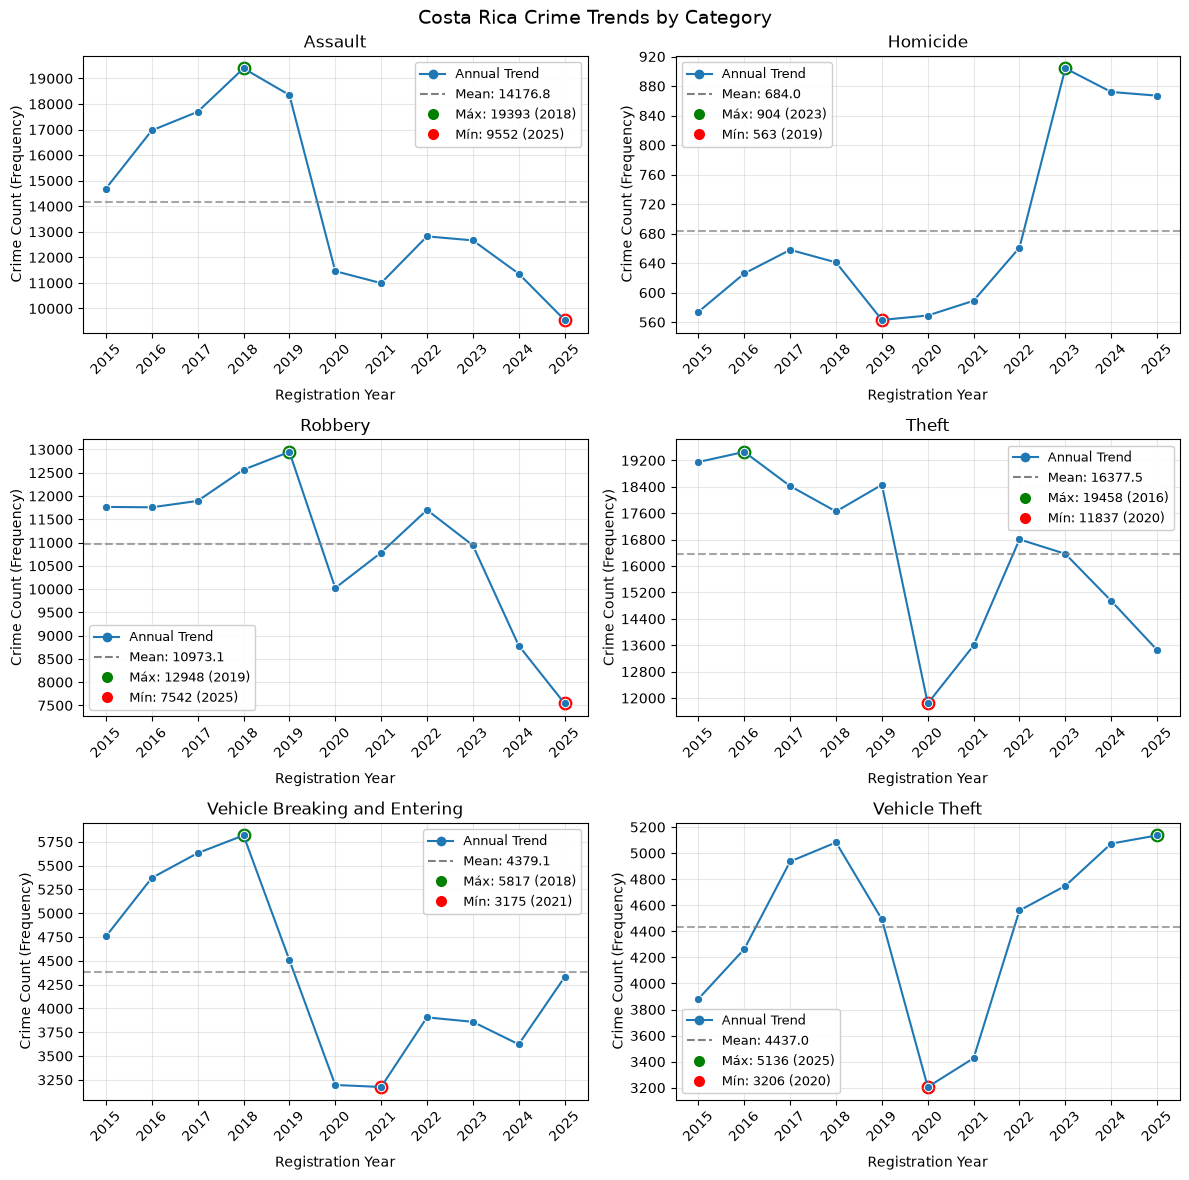

In [13]:
crimes = crimes_by_year["Crime_category"].unique()

fig, axes = plt.subplots(
    nrows=3,
    ncols= 2,
    figsize=(12, 12))

axes = axes.flatten()

for i, crime in enumerate(crimes):
    subset = crimes_by_year[crimes_by_year["Crime_category"] == crime].copy()

    # Calculate Statistics
    mean_val = subset["Count"].mean()
    max_row = subset.loc[subset["Count"].idxmax()]
    min_row = subset.loc[subset["Count"].idxmin()]

    ax = axes[i]

    # Plot the main trend line
    sns.lineplot(
        data=subset,
        x="Year",
        y="Count",
        marker="o",
        ax=ax
    )

    ax.set_xlabel("Registration Year", fontsize=10, labelpad=8)
    ax.set_ylabel("Crime Count (Frequency)", fontsize=10, labelpad=8, rotation=90, va="center")

    ax.axhline(mean_val, linestyle="--", color="gray", alpha=0.7)

    # Highlight Max and Min points
    ax.scatter(max_row["Year"], max_row["Count"], color="green", s=80, label="Max")
    ax.scatter(min_row["Year"], min_row["Count"], color="red", s=80, label="Min")

    ax.set_title(crime)
    ax.grid(True, alpha=0.3)

    # X and Y axis formatting
    ax.set_xticks(subset["Year"].unique())
    ax.set_xticklabels(subset["Year"].unique(), rotation=45)

    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=12))

    # Create the custom statistical legend entries
    legend_elements = [
        Line2D([0], [0], color="tab:blue", marker="o", label="Annual Trend"),
        Line2D([0], [0], color="gray", linestyle="--", label=f"Mean: {mean_val:.1f}"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="green", markersize=9, 
               label=f"Máx: {int(max_row['Count'])} ({int(max_row['Year'])})"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markersize=9, 
               label=f"Mín: {int(min_row['Count'])} ({int(min_row['Year'])})")
    ]
    
    ax.legend(handles=legend_elements, loc="best", fontsize=9, framealpha=0.95, facecolor="white")


plt.suptitle("Costa Rica Crime Trends by Category", fontsize=14)
plt.tight_layout()


save_path = '../reports/figures/crime_trends_by_category.png'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=400)

plt.show()

Visual trends clearly show a significant impact of the COVID-19 pandemic on most crime categories in 2020–2021, resulting in a noticeable drop. Homicides, however, are an exception, as they did not experience a similar decrease during this period.

#### Crimes rates by Province

Crime trends are being analyzed across all provinces. Since raw crime counts are heavily influenced by local population sizes, a normalization step is necessary for fair comparison. Crimes are converted into a rate per 100,000 inhabitants by dividing the total crime count per province by its population for each year and then multiplying by 100,000. This process combines the annual population dataset with the crime dataset.

#### Crime Rates and Trends

Analysis focusing on normalized crime rates and proportional category shares.

In [14]:
population_by_province = population_by_province.melt(
    id_vars="Province",
    var_name="Year",
    value_name="Province_population")
population_by_province["Year"] = population_by_province["Year"].astype(int)
population_by_province


,Province,Year,Province_population
0,Alajuela,2015,977423
1,Cartago,2015,513655
2,Guanacaste,2015,371871
3,Heredia,2015,494099
4,Limón,2015,424487
...,...,...,...
72,Guanacaste,2025,413767
73,Heredia,2025,546438
74,Limón,2025,455802
75,Puntarenas,2025,505637


This cell calculates the total population for each province for every year from 2015 to 2025.

In [15]:
crimes_year_prov = (
    crime_data
    .groupby(["Province", "Year", "Crime_category"], as_index=False)
    .size()
    .rename(columns={"size": "Count"})
    .sort_values(["Province", "Year", "Crime_category"])
    .reset_index(drop=True)
)
crimes_year_prov

,Province,Year,Crime_category,Count
0,Alajuela,2015,Assault,1714
1,Alajuela,2015,Homicide,56
2,Alajuela,2015,Robbery,2620
3,Alajuela,2015,Theft,3293
4,Alajuela,2015,Vehicle Breaking and Entering,708
...,...,...,...,...
457,San José,2025,Homicide,287
458,San José,2025,Robbery,1797
459,San José,2025,Theft,5606
460,San José,2025,Vehicle Breaking and Entering,1964


This cell provides crime counts grouped by year and province, which is essential for analyzing trends across different regions of Costa Rica. The output will be visualized to identify patterns and correlations between crime rates, population metrics, and socioeconomic factors.

In [16]:
# Merge with population data
crimes_year_prov = crimes_year_prov.merge(
    population_by_province,
    on=["Province", "Year"],
    how="left"
)
crimes_year_prov

,Province,Year,Crime_category,Count,Province_population
0,Alajuela,2015,Assault,1714,977423
1,Alajuela,2015,Homicide,56,977423
2,Alajuela,2015,Robbery,2620,977423
3,Alajuela,2015,Theft,3293,977423
4,Alajuela,2015,Vehicle Breaking and Entering,708,977423
...,...,...,...,...,...
457,San José,2025,Homicide,287,1662138
458,San José,2025,Robbery,1797,1662138
459,San José,2025,Theft,5606,1662138
460,San José,2025,Vehicle Breaking and Entering,1964,1662138


The provincial population data is being merged into the province-level crime DataFrame to enable the calculation of crime rates per capita.

The crime rate is calculated by dividing the total reported crimes by the provincial population and multiplying by 100,000 to express it as a rate per 100,000 inhabitants.

In [17]:
crimes_year_prov["Rate_per_100k"] = (
    crimes_year_prov["Count"] / crimes_year_prov["Province_population"] * 100000
)

display(crimes_year_prov.head(3))
display(crimes_year_prov.tail(3))

,Province,Year,Crime_category,Count,Province_population,Rate_per_100k
0,Alajuela,2015,Assault,1714,977423,175.359082
1,Alajuela,2015,Homicide,56,977423,5.729352
2,Alajuela,2015,Robbery,2620,977423,268.051806


,Province,Year,Crime_category,Count,Province_population,Rate_per_100k
459,San José,2025,Theft,5606,1662138,337.276448
460,San José,2025,Vehicle Breaking and Entering,1964,1662138,118.161067
461,San José,2025,Vehicle Theft,1725,1662138,103.781996


Each crime category is being plotted individually to provide a clearer and more appropriate visualization of distinct historical trends across provinces.

In [18]:
def plot_crime_rate(crime_type):
    data = crimes_year_prov[crimes_year_prov["Crime_category"] == crime_type]

    national_pop = population_by_province.groupby("Year")["Province_population"].sum().reset_index()
    national_pop.columns = ["Year", "Population"]

    national_crime = (
        crimes_year_prov[crimes_year_prov["Crime_category"] == crime_type]
        .groupby("Year")["Count"]
        .sum()
        .reset_index()
    )

    national_rate = national_crime.merge(national_pop, on="Year")
    national_rate["Rate_per_100k"] = national_rate["Count"] / national_rate["Population"] * 100000

    fig, ax = plt.subplots(figsize=(12, 6))

    sns.lineplot(
        data=data,
        x="Year",
        y="Rate_per_100k",
        hue="Province",
        marker="o",
        ax=ax
    )

    ax.set_xticks(sorted(data["Year"].unique()))
    ax.set_xticklabels(
        sorted(data["Year"].unique()),
        rotation=45
    )

    ax.plot(
        national_rate["Year"],
        national_rate["Rate_per_100k"],
        color="black",
        linestyle="--",
        marker="s",
        linewidth=2,
        alpha=0.5,
        label="National rate"
    )

    ax.legend()

    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=22))

    ax.set_title(f"{crime_type} by Province")
    ax.set_xlabel("Year")
    ax.set_ylabel(f"Rate per 100.000 inhabitants")

    ax.grid(alpha=0.3)

    plt.tight_layout()
    save_path = f'../reports/figures/{crime_type.replace(" ", "_")}_trends_by_province.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=400)
    plt.show()


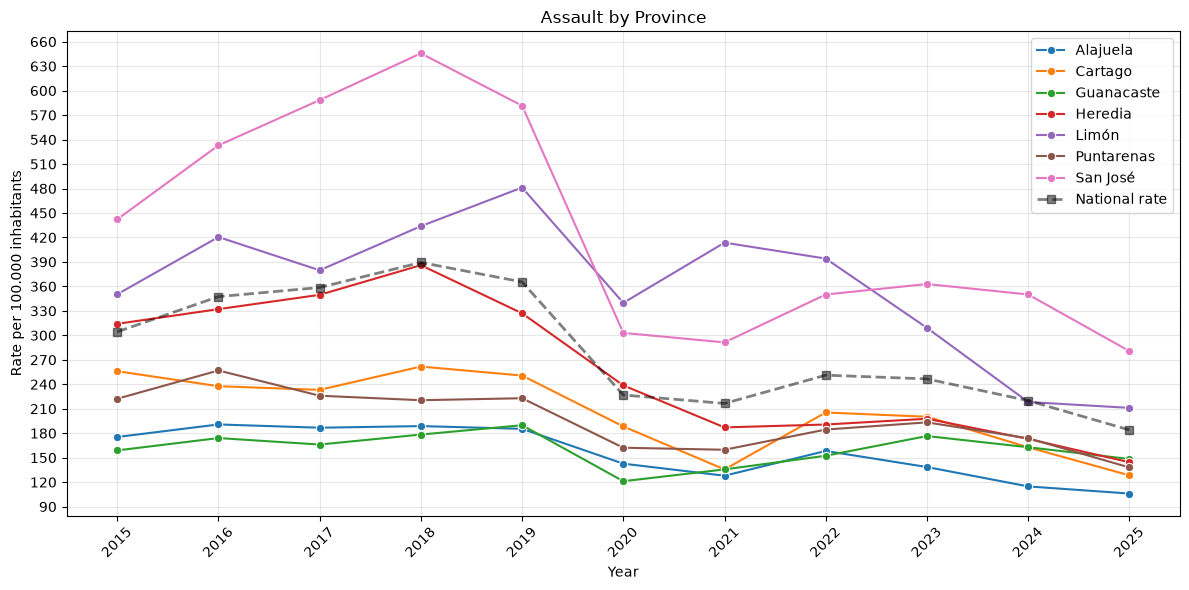

In [19]:
plot_crime_rate("Assault")

San José and Limón consistently show assault rates higher than the national average. However, from 2023 to 2025, a widespread downward trend in assault rates is observable across most provinces.

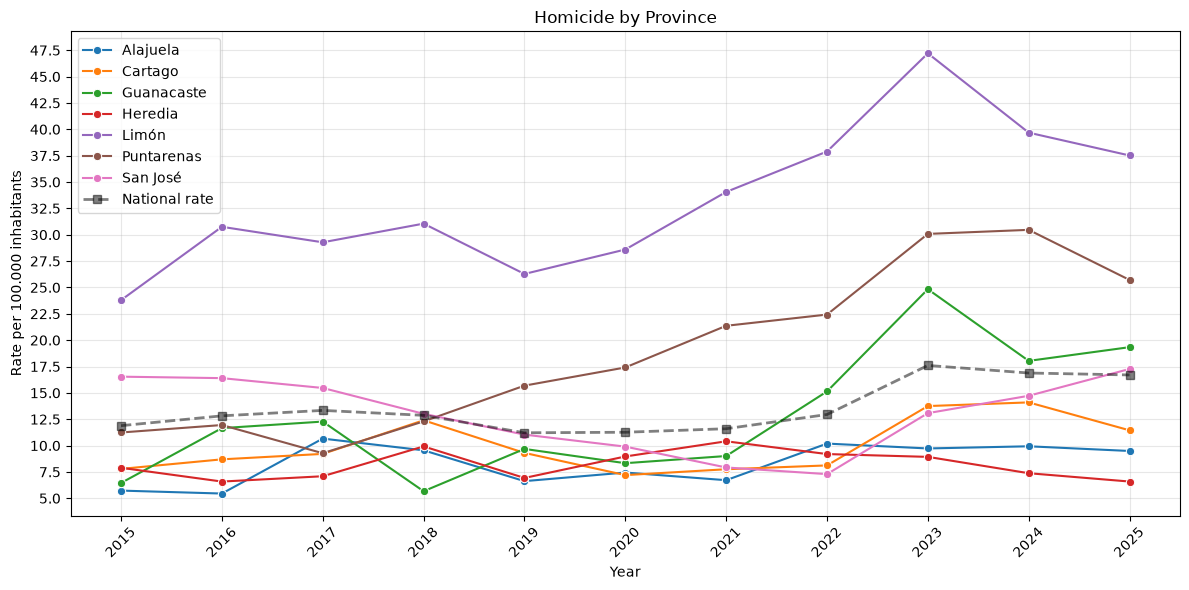

In [20]:
plot_crime_rate("Homicide")

Homicide rates exhibit a distinct pattern compared to other crime types, with the highest values appearing in coastal provinces, especially in recent years.

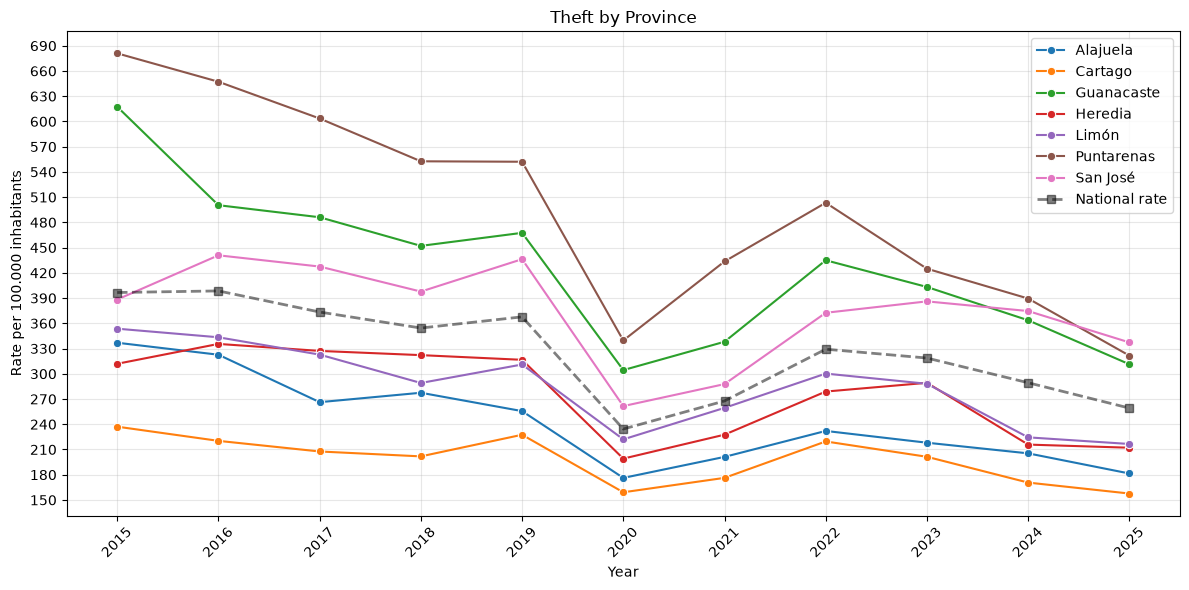

In [21]:
plot_crime_rate("Theft")

Theft shows a pattern similar to homicides: coastal provinces tend to experience higher rates, even as the national theft trend decreases over time.

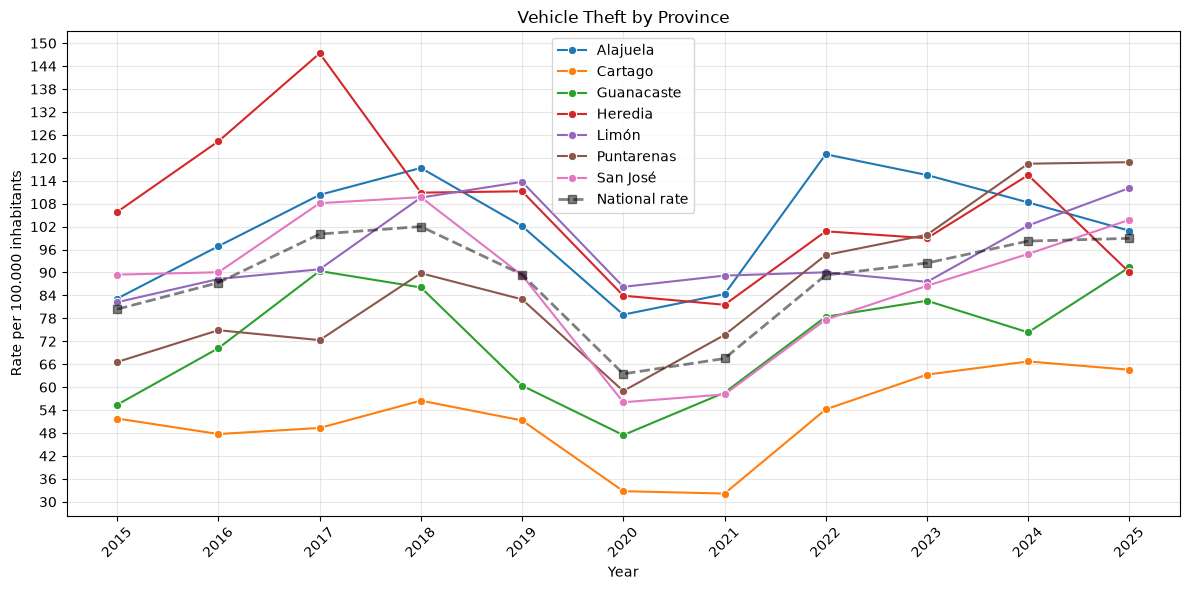

In [22]:
plot_crime_rate("Vehicle Theft")

Heredia and Alajuela stand out specifically for vehicle theft. These provinces display higher vehicle theft rates than expected when compared to other crime categories.

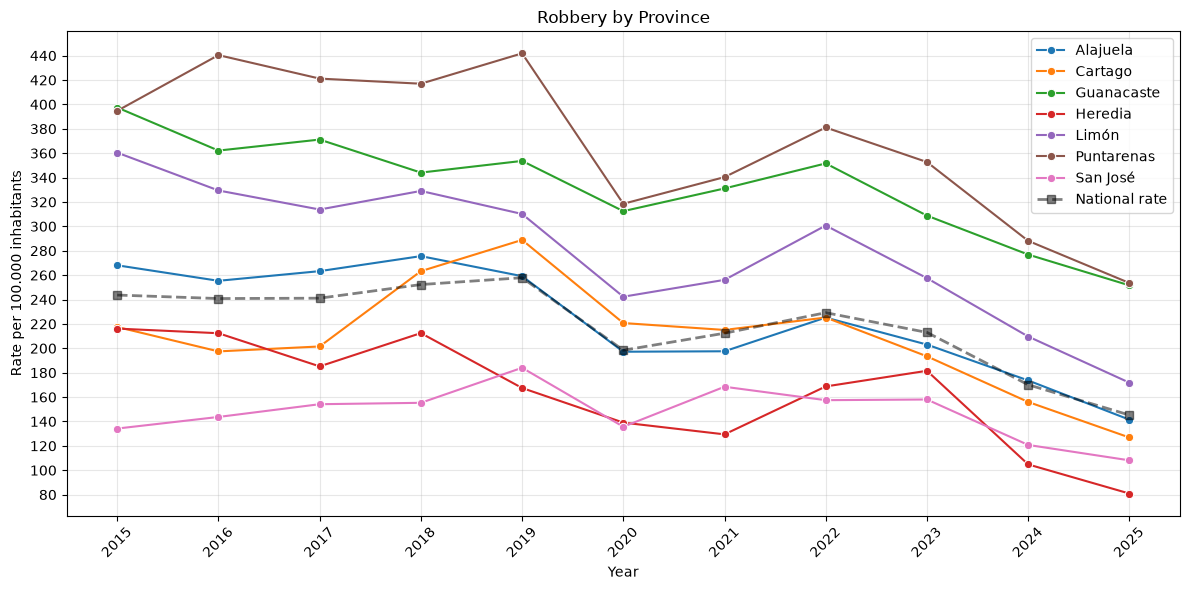

In [23]:
plot_crime_rate("Robbery")

Puntarenas and Guanacaste show the highest robbery rates. This pattern is consistent with the coastal concentration observed in other crime types.

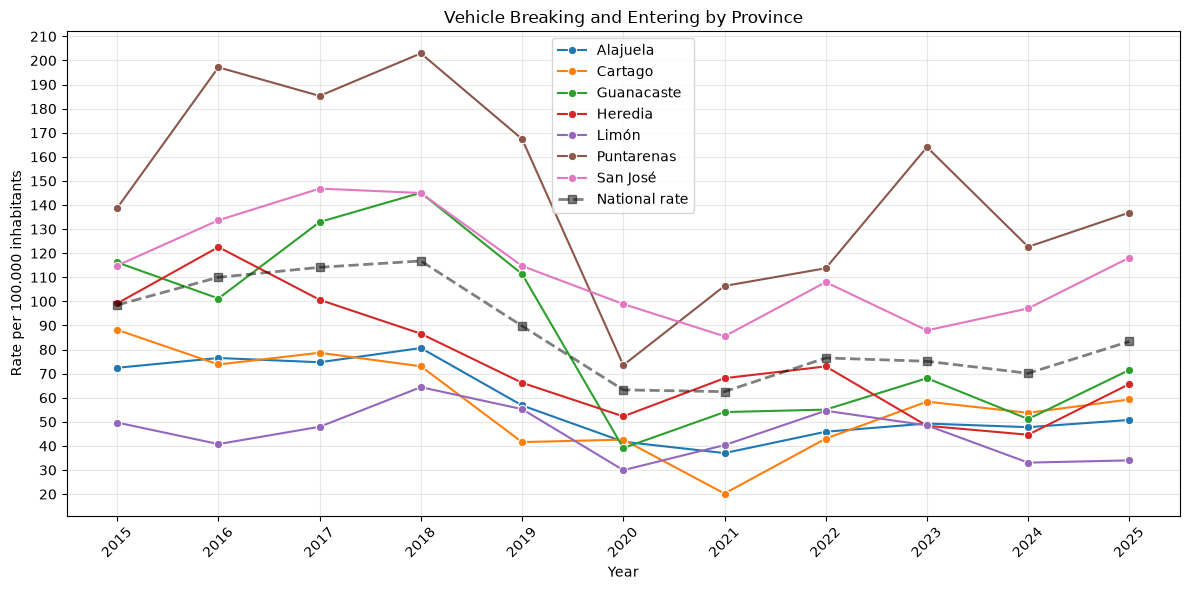

In [24]:
plot_crime_rate("Vehicle Breaking and Entering")

Puntarenas appears to have the highest rate of vehicle breaking and entering, indicating a significant concentration of this crime in that province.

After normalizing crime data by population, coastal provinces continue to exhibit higher crime rates across many categories, highlighting persistent regional disparities.

#### Proportional Share by Crime Category and Province

A proportional share analysis is conducted to examine the specific composition of crime within each province. Converting crime counts into proportions simplifies visualization and significantly improves readability, making it easier to understand the relative prevalence of different crime types.

In [25]:
crimes_year_prov.head(10)

,Province,Year,Crime_category,Count,Province_population,Rate_per_100k
0,Alajuela,2015,Assault,1714,977423,175.359082
1,Alajuela,2015,Homicide,56,977423,5.729352
2,Alajuela,2015,Robbery,2620,977423,268.051806
3,Alajuela,2015,Theft,3293,977423,336.906334
4,Alajuela,2015,Vehicle Breaking and Entering,708,977423,72.435373
5,Alajuela,2015,Vehicle Theft,813,977423,83.177908
6,Alajuela,2016,Assault,1890,990846,190.746090
7,Alajuela,2016,Homicide,54,990846,5.449888
8,Alajuela,2016,Robbery,2530,990846,255.337358
9,Alajuela,2016,Theft,3197,990846,322.653571


The crime proportions are calculated based on the total reported crimes within each category for every province, showing the relative share of each crime type.

In [26]:
province_year_crime = (
    crimes_year_prov
    .groupby(["Province", "Year", "Crime_category"], as_index=False)["Count"]
    .sum()
)
province_year_crime
province_year_crime["Share_pct"] = (
    province_year_crime["Count"]
    / province_year_crime.groupby(["Province", "Year"])["Count"].transform("sum")
    * 100
)

province_year_crime = province_year_crime.sort_values(
    ["Province", "Year", "Crime_category"]
).reset_index(drop=True)

province_year_crime

,Province,Year,Crime_category,Count,Share_pct
0,Alajuela,2015,Assault,1714,18.622338
1,Alajuela,2015,Homicide,56,0.608431
2,Alajuela,2015,Robbery,2620,28.465884
3,Alajuela,2015,Theft,3293,35.777923
4,Alajuela,2015,Vehicle Breaking and Entering,708,7.692308
...,...,...,...,...,...
457,San José,2025,Homicide,287,1.788831
458,San José,2025,Robbery,1797,11.200449
459,San José,2025,Theft,5606,34.941411
460,San José,2025,Vehicle Breaking and Entering,1964,12.241336


In [27]:
def plot_share_trend_by_province(province):
    province_data = province_year_crime[province_year_crime["Province"] == province].copy()
    year_labels = sorted(province_data["Year"].unique())

    fig, ax = plt.subplots(figsize=(12,6))

    sns.lineplot(
        data=province_data,
        x="Year",
        y="Share_pct",
        hue="Crime_category",
        marker="o",
        ax=ax
    )

    ax.set_xticks(year_labels)
    ax.set_xticklabels(year_labels, rotation=45)
    
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=22))


    ax.set_title(f"Crime Composition by Category - {province}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Percentage  of total crimes (%)")
    
    ax.grid(alpha=0.3)

    ax.legend(
        title="Crime category",
        bbox_to_anchor=(1, 1),
        loc="upper left",
    )

    fig.tight_layout(rect=[0, 0, 0.85, 1])
    
    save_path = f'../reports/figures/{province.replace(" ", "_")}_share_trends.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=400)
    plt.show()

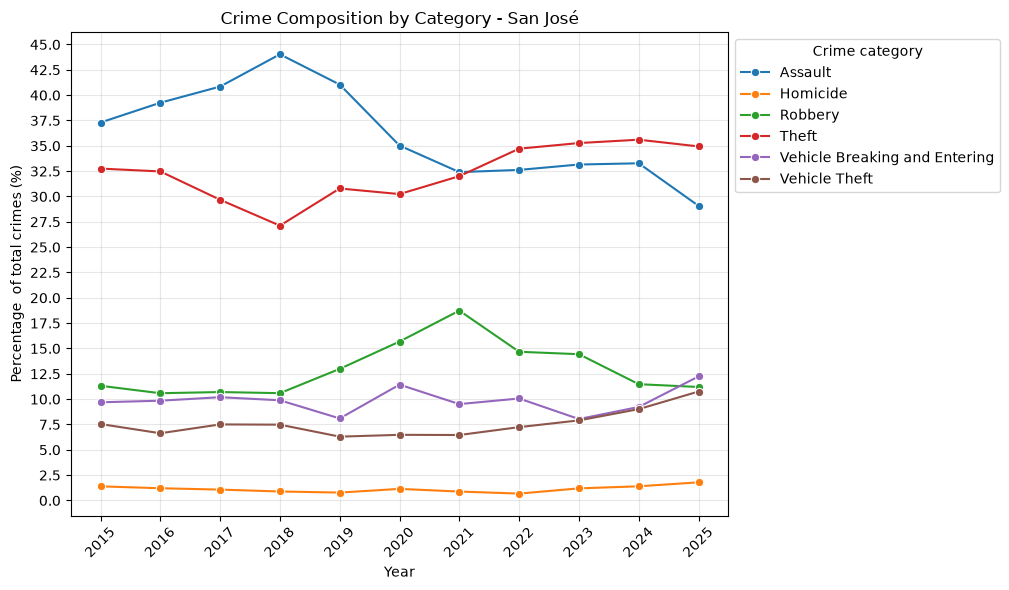

In [28]:
plot_share_trend_by_province("San José")

San José shows a high proportional share of both assault and theft. Notably, the share of robberies sharply increased between 2018 and 2021 before entering a steady decline in the subsequent years.

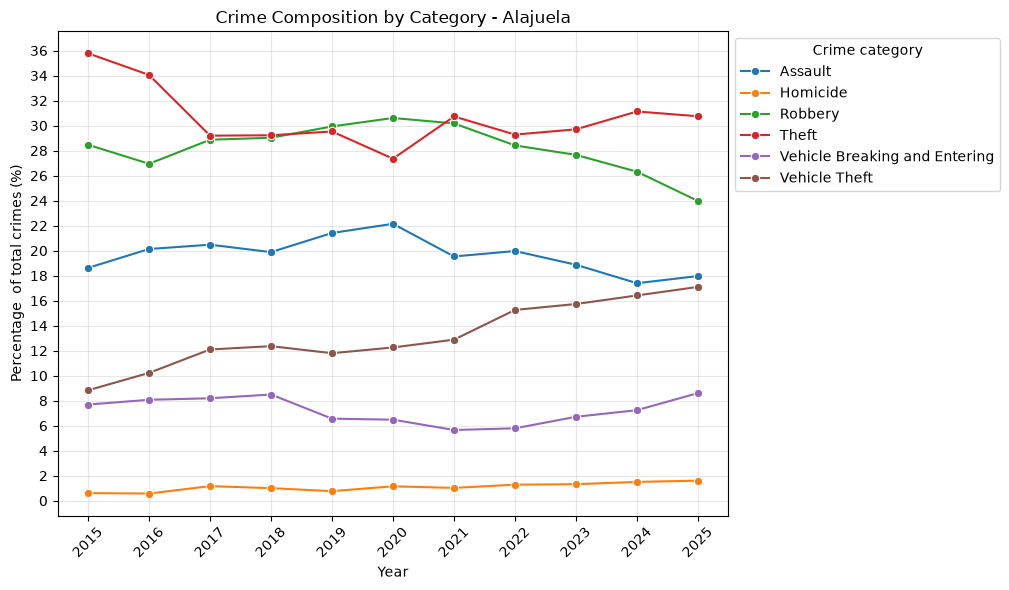

In [29]:
plot_share_trend_by_province("Alajuela")

Alajuela accounts for a large proportional share of robbery and theft. Over time, the proportion of vehicle theft shows an upward trajectory, while the share of robbery experiences a decline after 2020.

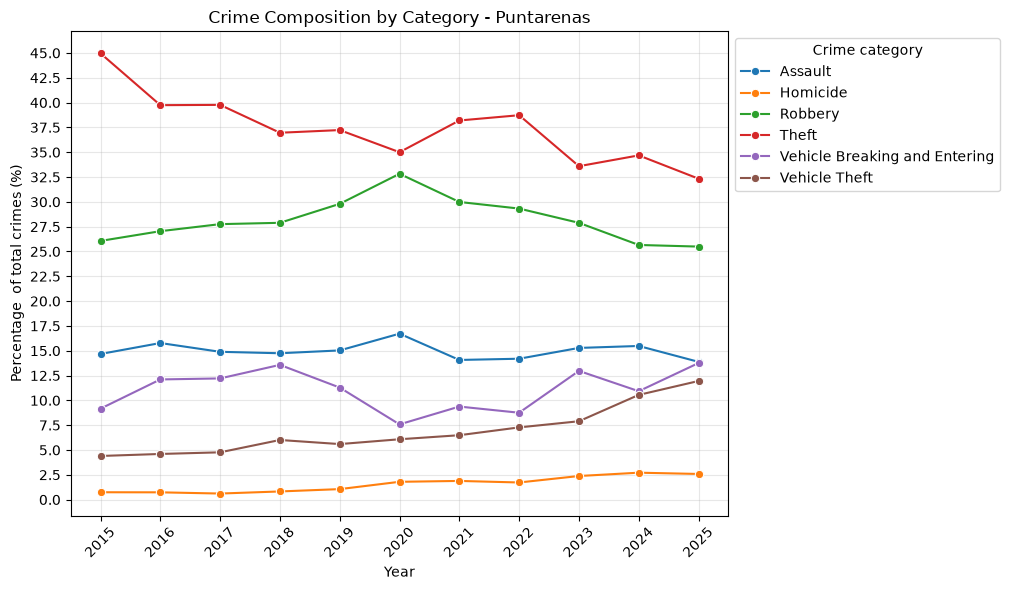

In [30]:
plot_share_trend_by_province("Puntarenas")

Puntarenas shows a shrinking proportional share of theft over time, which contrasts with a rising proportion of vehicle theft. Meanwhile, the share of assaults appears relatively stable.

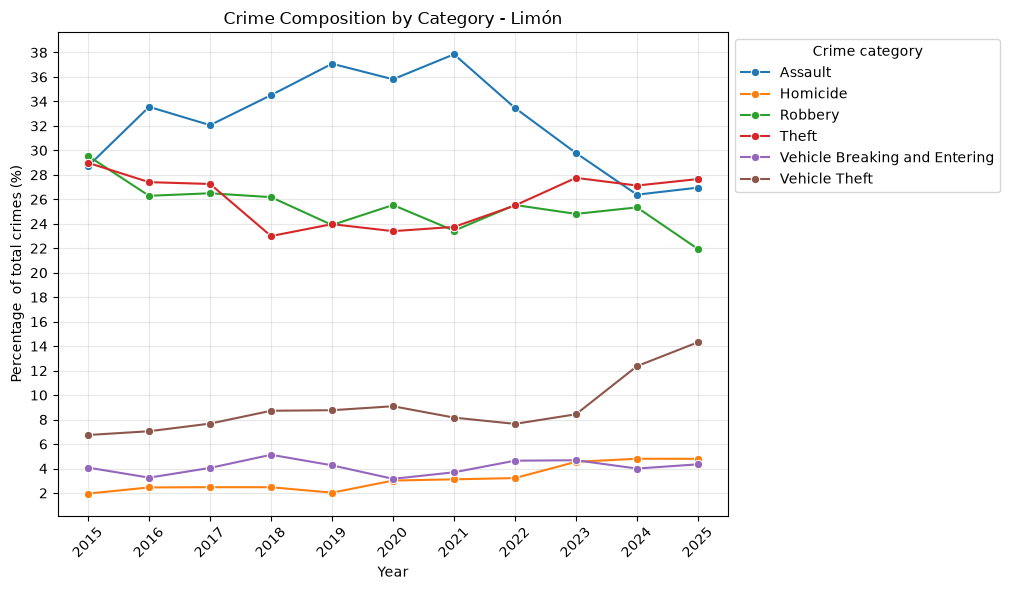

In [31]:
plot_share_trend_by_province("Limón")

Limón exhibits a sharp increase in its homicide share, doubling from approximately 2% to nearly 4% over the analyzed period. Additionally, vehicle theft and assault shares show notable fluctuations over time.

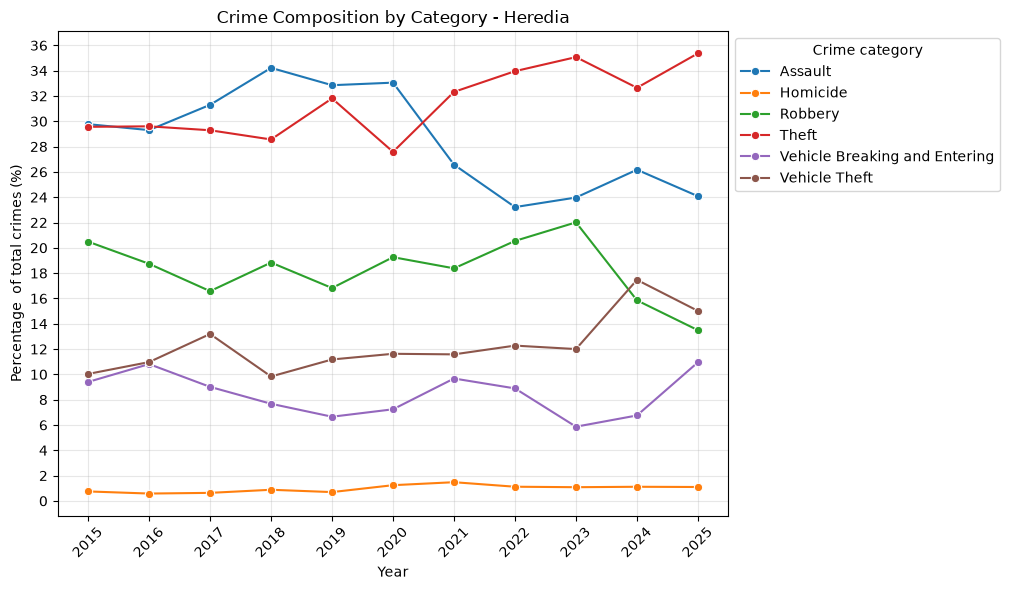

In [32]:
plot_share_trend_by_province("Heredia")

Heredia does not present a single, defining long-term pattern across all crime types. While the homicide share remains fairly constant, vehicle theft and Vehicle Breaking and Entering proportions experience more pronounced changes after 2021.

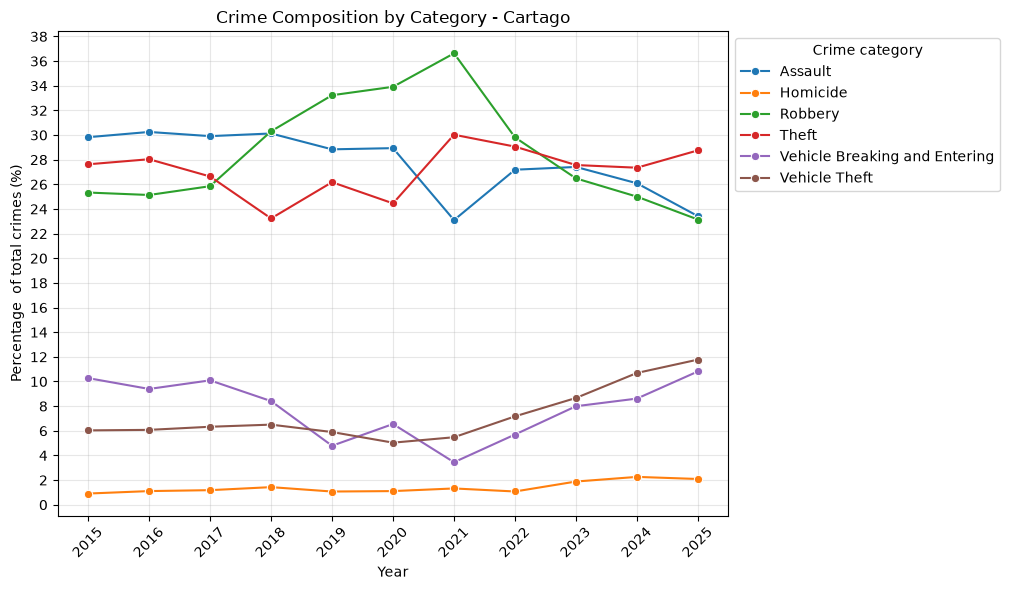

In [33]:
plot_share_trend_by_province("Cartago")

Cartago displays increasing proportional shares of both vehicle theft and vehicle breaking and entering. Conversely, the proportional shares of robbery, theft, and assault decline after 2022, while the homicide share stays stable.

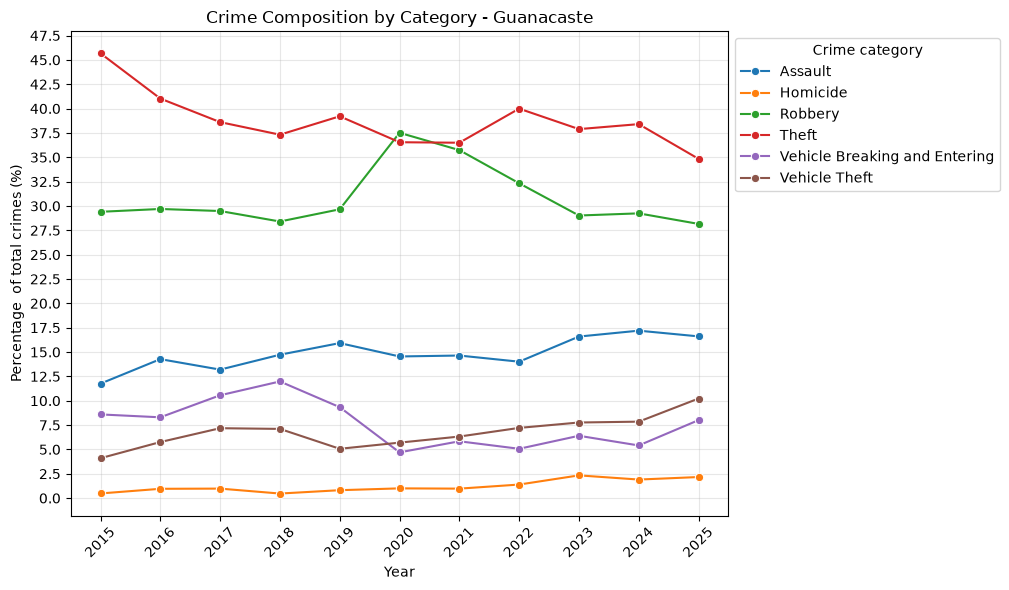

In [34]:
plot_share_trend_by_province("Guanacaste")

Guanacaste maintains a low proportional share of assaults compared to theft and robbery. The overall compositional pattern does not exhibit a clear long-term trend over the analyzed period.

### Demographic Analysis

This section introduces a provincial-level demographic correlation and regression model. By evaluating population density and growth rates as independent variables, we will assess their statistical relationship with localized crime trends, aiming to uncover potential socioeconomic patterns across Costa Rica.

In [35]:
population_data = crimes_year_prov.merge(
    population_indicators[["Province", "Year", "Growth_Rate_per_100", "Population_Density"]],  # Solo las columnas necesarias
    on=["Province", "Year"],
    how="left"
)
display(population_data.head(10))

,Province,Year,Crime_category,Count,Province_population,Rate_per_100k,Growth_Rate_per_100,Population_Density
0,Alajuela,2015,Assault,1714,977423,175.359082,1.43,99.63
1,Alajuela,2015,Homicide,56,977423,5.729352,1.43,99.63
2,Alajuela,2015,Robbery,2620,977423,268.051806,1.43,99.63
3,Alajuela,2015,Theft,3293,977423,336.906334,1.43,99.63
4,Alajuela,2015,Vehicle Breaking and Entering,708,977423,72.435373,1.43,99.63
5,Alajuela,2015,Vehicle Theft,813,977423,83.177908,1.43,99.63
6,Alajuela,2016,Assault,1890,990846,190.746090,1.36,100.99
7,Alajuela,2016,Homicide,54,990846,5.449888,1.36,100.99
8,Alajuela,2016,Robbery,2530,990846,255.337358,1.36,100.99
9,Alajuela,2016,Theft,3197,990846,322.653571,1.36,100.99


In [36]:
population_data = (
    population_data.pivot_table(
        index=["Province", "Year", "Population_Density", "Growth_Rate_per_100"],
        columns="Crime_category",
        values="Rate_per_100k"
    ).reset_index()
)
population_data

Crime_category,Province,Year,Population_Density,Growth_Rate_per_100,Assault,Homicide,Robbery,Theft,Vehicle Breaking and Entering,Vehicle Theft
0,Alajuela,2015,99.63,1.43,175.359082,5.729352,268.051806,336.906334,72.435373,83.177908
1,Alajuela,2016,100.99,1.36,190.746090,5.449888,255.337358,322.653571,76.500284,96.886903
2,Alajuela,2017,102.29,1.28,186.733176,10.661926,263.259899,266.249224,74.733128,110.306097
3,Alajuela,2018,103.53,1.20,188.736274,9.550036,275.572682,277.443308,80.633807,117.357141
4,Alajuela,2019,104.59,1.02,185.362050,6.627034,259.136536,255.628106,56.817074,102.134295
...,...,...,...,...,...,...,...,...,...,...
72,San José,2021,330.14,0.28,291.333025,7.923283,168.461189,287.737074,85.510509,58.083760
73,San José,2022,331.11,0.29,350.034730,7.292390,157.454859,372.519600,107.988145,77.663956
74,San José,2023,332.36,0.38,362.884111,13.076905,158.012601,386.071401,87.966402,86.513413
75,San José,2024,333.47,0.33,350.090238,14.722857,120.739498,374.588107,97.086383,94.853818


The dataset is structured by province and year, with each row representing a unique observation, making it suitable for panel data analysis.

In [37]:
population_data = population_data.rename(columns={
    "Assault": "Rate_Assault_per_100k",
    "Homicide": "Rate_Homicide_per_100k",
    "Robbery": "Rate_Robbery_per_100k",
    "Theft": "Rate_Theft_per_100k",
    "Vehicle Breaking and Entering": "Rate_Vehicle_Breaking_and_Entering_per_100k",
    "Vehicle Theft": "Rate_Vehicle_Theft_per_100k",
})

display(population_data.head(20))

Crime_category,Province,Year,Population_Density,Growth_Rate_per_100,Rate_Assault_per_100k,Rate_Homicide_per_100k,Rate_Robbery_per_100k,Rate_Theft_per_100k,Rate_Vehicle_Breaking_and_Entering_per_100k,Rate_Vehicle_Theft_per_100k
0,Alajuela,2015,99.63,1.43,175.359082,5.729352,268.051806,336.906334,72.435373,83.177908
1,Alajuela,2016,100.99,1.36,190.746090,5.449888,255.337358,322.653571,76.500284,96.886903
2,Alajuela,2017,102.29,1.28,186.733176,10.661926,263.259899,266.249224,74.733128,110.306097
3,Alajuela,2018,103.53,1.20,188.736274,9.550036,275.572682,277.443308,80.633807,117.357141
4,Alajuela,2019,104.59,1.02,185.362050,6.627034,259.136536,255.628106,56.817074,102.134295
5,Alajuela,2020,105.45,0.82,142.664659,7.442533,197.178797,176.204385,41.755510,78.968175
6,Alajuela,2021,106.23,0.74,127.895274,6.716181,197.551664,201.197591,37.034940,84.336043
7,Alajuela,2022,107.04,0.76,158.257077,10.188633,225.197345,232.053248,45.896457,120.930498
8,Alajuela,2023,107.93,0.83,138.540649,9.727121,203.041850,218.057503,49.296672,115.497759
9,Alajuela,2024,108.78,0.78,114.786357,9.932534,173.631934,205.397301,47.788606,108.320840


The crime rate columns were renamed to improve the table's readability and ensure consistent formatting for easier interpretation.

### Provincial-Level Correlation Analysis

This subsection explores the specific correlation coefficients between demographic indicators and crime categories across individual provinces. By analyzing these relationships at the provincial level, we can identify unique regional patterns that might be hidden in national-level data.

The Spearman rank correlation is utilized for this analysis due to the following statistical characteristics of the dataset:

- **Monotonicity:** Spearman assesses monotonic relationships, whether linear or not, which is appropriate for complex social data.

- **Robustness:** It is less sensitive to extreme outliers, which are present in certain crime peaks (e.g., 2023 homicide rates).

- **Distributional Assumptions:** Spearman does not assume normal distribution of the variables, providing a more reliable measure for provincial crime and demographic data.

In [38]:
crime_rate_columns = [col for col in population_data.columns if col.startswith("Rate_")]
crime_rate_columns

['Rate_Assault_per_100k',
 'Rate_Homicide_per_100k',
 'Rate_Robbery_per_100k',
 'Rate_Theft_per_100k',
 'Rate_Vehicle_Breaking_and_Entering_per_100k',
 'Rate_Vehicle_Theft_per_100k']

In [39]:
demographic_categories = ["Population_Density", "Growth_Rate_per_100"] 

Annual crime growth was excluded from this analysis because it is highly correlated with the general population growth rate, which is already being considered.

In [40]:
import dataframe_image as dfi

In [41]:
def calculate_province_correlations(prov):
    prov_df = population_data[population_data["Province"] == prov]
    corr_prov = prov_df[demographic_categories + crime_rate_columns].corr(method="spearman").loc[demographic_categories, crime_rate_columns]
    
    records = []
    for crime in crime_rate_columns:
        records.append({
            'Province': prov,
            'Crime': crime,
            'Growth_Rate_Corr': corr_prov.loc['Growth_Rate_per_100', crime],
            'Density_Corr': corr_prov.loc['Population_Density', crime]
        })

    corr_by_province = pd.DataFrame(records).round(3)

    save_path = f'../reports/tables/correlation_{prov}.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    dfi.export(
        corr_by_province, 
        save_path, 
        table_conversion='matplotlib'
    )
    
    return corr_by_province[corr_by_province["Province"] == prov]

In [42]:
calculate_province_correlations("San José")

,Province,Crime,Growth_Rate_Corr,Density_Corr
0,San José,Rate_Assault_per_100k,0.797,-0.682
1,San José,Rate_Homicide_per_100k,0.501,-0.173
2,San José,Rate_Robbery_per_100k,-0.105,-0.109
3,San José,Rate_Theft_per_100k,0.788,-0.627
4,San José,Rate_Vehicle_Breaking_and_Entering_per_100k,0.633,-0.555
5,San José,Rate_Vehicle_Theft_per_100k,0.419,-0.164


In San José:

*   **Assault** shows a moderate positive correlation with `Growth_Rate_per_100` (0.797) and a moderate negative correlation with `Population_Density` (-0.682).
*   **Theft** also has a moderate positive correlation with `Growth_Rate_per_100` (0.788) and a moderate negative correlation with `Population_Density` (-0.627).

This indicates that in San José, higher population growth is generally associated with increased rates of Assault and Theft, while higher population density tends to correlate with lower rates of these crimes.

In [43]:
calculate_province_correlations("Alajuela")

,Province,Crime,Growth_Rate_Corr,Density_Corr
0,Alajuela,Rate_Assault_per_100k,0.811,-0.855
1,Alajuela,Rate_Homicide_per_100k,-0.310,0.455
2,Alajuela,Rate_Robbery_per_100k,0.797,-0.827
3,Alajuela,Rate_Theft_per_100k,0.861,-0.800
4,Alajuela,Rate_Vehicle_Breaking_and_Entering_per_100k,0.779,-0.618
5,Alajuela,Rate_Vehicle_Theft_per_100k,-0.073,0.264


In Alajuela:

*   **Assault** shows a strong positive correlation with `Growth_Rate_per_100` (0.811) and a strong negative correlation with `Population_Density` (-0.855).
*   **Robbery** has a moderate positive correlation with `Growth_Rate_per_100` (0.797) and a strong negative correlation with `Population_Density` (-0.827).
*   **Theft** shows a very strong positive correlation with `Growth_Rate_per_100` (0.861) and a strong negative correlation with `Population_Density` (-0.800).
*   **Vehicle Breaking and Entering** also has a moderate positive correlation with `Growth_Rate_per_100` (0.779) and a moderate negative correlation with `Population_Density` (-0.618).

These results suggest that in Alajuela, increased population growth is strongly associated with higher rates of Assault, Robbery, Theft, and Vehicle Breaking and Entering, while higher population density is strongly linked to lower rates of these same crimes. 

In [44]:
calculate_province_correlations("Puntarenas")

,Province,Crime,Growth_Rate_Corr,Density_Corr
0,Puntarenas,Rate_Assault_per_100k,0.877,-0.782
1,Puntarenas,Rate_Homicide_per_100k,-0.804,0.945
2,Puntarenas,Rate_Robbery_per_100k,0.735,-0.773
3,Puntarenas,Rate_Theft_per_100k,0.831,-0.900
4,Puntarenas,Rate_Vehicle_Breaking_and_Entering_per_100k,0.680,-0.518
5,Puntarenas,Rate_Vehicle_Theft_per_100k,-0.525,0.755


In Puntarenas:

*   **Assault** shows a very strong positive correlation with `Growth_Rate_per_100` (0.877) and a moderate negative correlation with `Population_Density` (-0.782).
*   **Robbery** has a moderate positive correlation with `Growth_Rate_per_100` (0.735) and a moderate negative correlation with `Population_Density` (-0.773).
*   **Theft** shows a very strong positive correlation with `Growth_Rate_per_100` (0.831) and a very strong negative correlation with `Population_Density` (-0.900).
*   **Homicide** shows a strong negative correlation with `Growth_Rate_per_100` (-0.804) and a very strong positive correlation with `Population_Density` (0.945).
*   **Vehicle Theft** has a weak negative correlation with `Growth_Rate_per_100` (-0.525) and a strong positive correlation with `Population_Density` (0.755).

This indicates a clear pattern in Puntarenas where most crime categories (Assault, Robbery, Theft, Vehicle Breaking and Entering) show strong positive correlations with population growth and strong negative correlations with population density. Homicide and Vehicle Theft, however, show the opposite trend, with strong negative correlations with population growth and strong positive correlations with population density.

In [45]:
calculate_province_correlations("Limón")

,Province,Crime,Growth_Rate_Corr,Density_Corr
0,Limón,Rate_Assault_per_100k,0.433,-0.600
1,Limón,Rate_Homicide_per_100k,-0.688,0.791
2,Limón,Rate_Robbery_per_100k,0.893,-0.909
3,Limón,Rate_Theft_per_100k,0.829,-0.836
4,Limón,Rate_Vehicle_Breaking_and_Entering_per_100k,0.405,-0.400
5,Limón,Rate_Vehicle_Theft_per_100k,-0.337,0.336


In Limón:

*   **Robbery** shows a very strong positive correlation with `Growth_Rate_per_100` (0.893) and a very strong negative correlation with `Population_Density` (-0.909).
*   **Theft** has a strong positive correlation with `Growth_Rate_per_100` (0.829) and a strong negative correlation with `Population_Density` (-0.836).
*   **Homicide** shows a moderate negative correlation with `Growth_Rate_per_100` (-0.688) and a moderate positive correlation with `Population_Density` (0.791).
*   **Assault** has a weak positive correlation with `Growth_Rate_per_100` (0.433) and a moderate negative correlation with `Population_Density` (-0.600).

These correlations indicate that in Limón, higher population growth is strongly associated with increased robbery and theft rates, while higher population density correlates with decreased rates of these crimes. Homicide and Vehicle Theft show an inverse relationship with these demographic indicators.

In [46]:
calculate_province_correlations("Guanacaste")

,Province,Crime,Growth_Rate_Corr,Density_Corr
0,Guanacaste,Rate_Assault_per_100k,0.474,-0.300
1,Guanacaste,Rate_Homicide_per_100k,-0.538,0.700
2,Guanacaste,Rate_Robbery_per_100k,0.793,-0.909
3,Guanacaste,Rate_Theft_per_100k,0.815,-0.800
4,Guanacaste,Rate_Vehicle_Breaking_and_Entering_per_100k,0.633,-0.627
5,Guanacaste,Rate_Vehicle_Theft_per_100k,-0.255,0.345


In Guanacaste:

*   **Robbery** shows a moderate positive correlation with `Growth_Rate_per_100` (0.793) and a very strong negative correlation with `Population_Density` (-0.909).
*   **Theft** has a strong positive correlation with `Growth_Rate_per_100` (0.815) and a strong negative correlation with `Population_Density` (-0.800).
*   **Homicide** shows a weak negative correlation with `Growth_Rate_per_100` (-0.538) and a moderate positive correlation with `Population_Density` (0.700).

This indicates that in Guanacaste, robbery and theft are strongly correlated with both demographic indicators, with positive correlations with population growth and negative correlations with population density. Homicides show the opposite pattern.

In [47]:
calculate_province_correlations("Heredia")

,Province,Crime,Growth_Rate_Corr,Density_Corr
0,Heredia,Rate_Assault_per_100k,0.845,-0.836
1,Heredia,Rate_Homicide_per_100k,-0.264,0.100
2,Heredia,Rate_Robbery_per_100k,0.855,-0.827
3,Heredia,Rate_Theft_per_100k,0.745,-0.736
4,Heredia,Rate_Vehicle_Breaking_and_Entering_per_100k,0.645,-0.818
5,Heredia,Rate_Vehicle_Theft_per_100k,0.627,-0.464


In Heredia:

*   **Assault** shows a strong positive correlation with `Growth_Rate_per_100` (0.845) and a strong negative correlation with `Population_Density` (-0.836).
*   **Robbery** has a strong positive correlation with `Growth_Rate_per_100` (0.855) and a strong negative correlation with `Population_Density` (-0.827).
*   **Theft** has a moderate positive correlation with `Growth_Rate_per_100` (0.745) and a moderate negative correlation with `Population_Density` (-0.736).
*   **Vehicle Breaking and Entering** shows a moderate positive correlation with `Growth_Rate_per_100` (0.645) and a strong negative correlation with `Population_Density` (-0.818).

In Heredia, both assault and robbery are strongly correlated with both demographic indicators (positive with growth rate, negative with density). Vehicle Breaking and Entering also shows a strong negative correlation with population density, suggesting that as density increases, this crime decreases.

In [48]:
calculate_province_correlations("Cartago")

,Province,Crime,Growth_Rate_Corr,Density_Corr
0,Cartago,Rate_Assault_per_100k,0.840,-0.800
1,Cartago,Rate_Homicide_per_100k,-0.059,0.418
2,Cartago,Rate_Robbery_per_100k,0.265,-0.464
3,Cartago,Rate_Theft_per_100k,0.712,-0.745
4,Cartago,Rate_Vehicle_Breaking_and_Entering_per_100k,0.699,-0.518
5,Cartago,Rate_Vehicle_Theft_per_100k,-0.210,0.555


In Cartago:

*   **Assault** shows a strong positive correlation with `Growth_Rate_per_100` (0.840) and a strong negative correlation with `Population_Density` (-0.800).
*   **Theft** has a moderate positive correlation with `Growth_Rate_per_100` (0.712) and a moderate negative correlation with `Population_Density` (-0.745).

In Cartago, a strong correlation with both demographic indicators exists exclusively for assault (positive with growth rate, negative with density).

### Regression Analysis: Demographic Indicators vs. Crime Rates

In [49]:
import statsmodels.formula.api as smf

In [50]:
population_data

Crime_category,Province,Year,Population_Density,Growth_Rate_per_100,Rate_Assault_per_100k,Rate_Homicide_per_100k,Rate_Robbery_per_100k,Rate_Theft_per_100k,Rate_Vehicle_Breaking_and_Entering_per_100k,Rate_Vehicle_Theft_per_100k
0,Alajuela,2015,99.63,1.43,175.359082,5.729352,268.051806,336.906334,72.435373,83.177908
1,Alajuela,2016,100.99,1.36,190.746090,5.449888,255.337358,322.653571,76.500284,96.886903
2,Alajuela,2017,102.29,1.28,186.733176,10.661926,263.259899,266.249224,74.733128,110.306097
3,Alajuela,2018,103.53,1.20,188.736274,9.550036,275.572682,277.443308,80.633807,117.357141
4,Alajuela,2019,104.59,1.02,185.362050,6.627034,259.136536,255.628106,56.817074,102.134295
...,...,...,...,...,...,...,...,...,...,...
72,San José,2021,330.14,0.28,291.333025,7.923283,168.461189,287.737074,85.510509,58.083760
73,San José,2022,331.11,0.29,350.034730,7.292390,157.454859,372.519600,107.988145,77.663956
74,San José,2023,332.36,0.38,362.884111,13.076905,158.012601,386.071401,87.966402,86.513413
75,San José,2024,333.47,0.33,350.090238,14.722857,120.739498,374.588107,97.086383,94.853818


In [51]:
population_data_reg = population_data.copy()
population_data_reg["Province"] = population_data_reg["Province"].astype("category")
population_data_reg["Year"] = population_data_reg["Year"].astype("category")
population_data_reg

Crime_category,Province,Year,Population_Density,Growth_Rate_per_100,Rate_Assault_per_100k,Rate_Homicide_per_100k,Rate_Robbery_per_100k,Rate_Theft_per_100k,Rate_Vehicle_Breaking_and_Entering_per_100k,Rate_Vehicle_Theft_per_100k
0,Alajuela,2015,99.63,1.43,175.359082,5.729352,268.051806,336.906334,72.435373,83.177908
1,Alajuela,2016,100.99,1.36,190.746090,5.449888,255.337358,322.653571,76.500284,96.886903
2,Alajuela,2017,102.29,1.28,186.733176,10.661926,263.259899,266.249224,74.733128,110.306097
3,Alajuela,2018,103.53,1.20,188.736274,9.550036,275.572682,277.443308,80.633807,117.357141
4,Alajuela,2019,104.59,1.02,185.362050,6.627034,259.136536,255.628106,56.817074,102.134295
...,...,...,...,...,...,...,...,...,...,...
72,San José,2021,330.14,0.28,291.333025,7.923283,168.461189,287.737074,85.510509,58.083760
73,San José,2022,331.11,0.29,350.034730,7.292390,157.454859,372.519600,107.988145,77.663956
74,San José,2023,332.36,0.38,362.884111,13.076905,158.012601,386.071401,87.966402,86.513413
75,San José,2024,333.47,0.33,350.090238,14.722857,120.739498,374.588107,97.086383,94.853818


This step is preparing the `population_data` DataFrame for regression modeling by creating a copy and converting the 'Province' and 'Year' columns to categorical types. This is essential for `statsmodels` to correctly interpret these variables as fixed effects in the regression model.

In [52]:
import numpy as np

In [53]:
regression_results = []

for crime in crime_rate_columns:
    formula = f"{crime} ~ Growth_Rate_per_100 + np.log(Population_Density) + C(Province) + C(Year)"
    

    model = smf.ols(formula=formula, data=population_data_reg).fit(cov_type="HC3")
    intervals = model.conf_int()
        
    growth_coef = model.params.get("Growth_Rate_per_100", np.nan)
    growth_p = model.pvalues.get("Growth_Rate_per_100", np.nan)
    growth_ci_lower = intervals.loc['Growth_Rate_per_100', 0] if 'Growth_Rate_per_100' in intervals.index else np.nan
    growth_ci_upper = intervals.loc['Growth_Rate_per_100', 1] if 'Growth_Rate_per_100' in intervals.index else np.nan

    density_coef = model.params.get("np.log(Population_Density)", np.nan)
    density_p = model.pvalues.get("np.log(Population_Density)", np.nan)
    density_ci_lower = intervals.loc['np.log(Population_Density)', 0] if 'np.log(Population_Density)' in intervals.index else np.nan
    density_ci_upper = intervals.loc['np.log(Population_Density)', 1] if 'np.log(Population_Density)' in intervals.index else np.nan

    regression_results.append({
        "Crime_Rate": crime,
        "Growth_Rate_Coef": growth_coef,
        "Growth_Rate_P": growth_p, 
        "Growth_Rate_CI_Lower": growth_ci_lower,
        "Growth_Rate_CI_Upper": growth_ci_upper,
        "Density_Coef": density_coef,
        "Density_P": density_p,
        "Density_CI_Lower": density_ci_lower,
        "Density_CI_Upper": density_ci_upper,
        "R2": model.rsquared,
        
        "Adj_R2": model.rsquared_adj,
    })


regression_results = pd.DataFrame(regression_results).round(3)
regression_results = regression_results.set_index('Crime_Rate').T.reset_index()
regression_results['index'] = regression_results['index'].str.replace('_', ' ')
regression_results.columns = [
    col.replace('Rate_', '').replace('_per_100k', '').replace('_', ' ') 
    if col != 'index' else 'Metric' 
    for col in regression_results.columns
]
save_path = f'../reports/tables/regression_results_population.png'
os.makedirs(os.path.dirname(save_path), exist_ok=True)

dfi.export(
    regression_results, 
    save_path, 
    table_conversion='matplotlib'
)



regression_results


,Metric,Assault,Homicide,Robbery,Theft,Vehicle Breaking and Entering,Vehicle Theft
0,Growth Rate Coef,-1569.489,-133.234,455.529,384.441,237.635,-328.828
1,Growth Rate P,0.003,0.001,0.028,0.319,0.239,0.030
2,Growth Rate CI Lower,-2620.233,-209.702,50.476,-371.023,-158.055,-625.205
3,Growth Rate CI Upper,-518.746,-56.766,860.582,1139.904,633.325,-32.451
4,Density Coef,18.966,-19.106,-673.507,-1787.645,-262.947,-303.225
5,Density P,0.980,0.748,0.081,0.005,0.403,0.297
6,Density CI Lower,-1495.341,-135.428,-1430.598,-3042.654,-879.621,-873.618
7,Density CI Upper,1533.274,97.217,83.585,-532.636,353.727,267.169
8,R2,0.897,0.898,0.958,0.939,0.886,0.833
9,Adj R2,0.864,0.867,0.946,0.920,0.851,0.781


For the provincial analysis, we are using a panel regression model with fixed effects. This approach allows to:

* **Control for unobserved provincial characteristics:** C(Province) captures any constant, unobservable factors unique to each province that might influence crime rates (e.g., historical context, geography).
* **Control for unobserved time-specific effects:** C(Year) accounts for any common trends affecting all provinces in a given year (e.g., national policy changes, economic shocks).
* **Address serial correlation within provinces:** cov_type='cluster' and cov_kwds={'groups': population_data_reg['Province']} are used to calculate robust standard errors. This clustering accounts for the fact that observations within the same province over time might be correlated, providing more reliable p-values and confidence intervals. This is crucial for avoiding biased inference when dealing with panel data.

After controlling for provincial and yearly effects, the model reveals that demographic changes are significantly linked to specific crime rates. The adjusted R-squared values, ranging from 0.78 to 0.95, indicate that the models explain a very high proportion of the variance in crime rates across categories, confirming the robustness of the findings.

Here's a breakdown of the key findings:

*   **Robbery**: A higher population density is strongly associated with a significant **decrease** in robbery rates (Coefficient: -673.51, p=0.00).
*   **Theft**: Higher population density is also strongly linked to a significant **decrease** in theft rates (Coefficient: -1787.65, p=0.05).
*   **Homicide**: A higher population growth rate significantly correlates with **fewer** homicides (Coefficient: -133.23, p=0.00).
*   **Assault**: This crime category did not show statistically reliable changes (p>0.05) in relation to demographic indicators, suggesting that other localized or non-demographic factors might be more influential.

### Macroeconomic Trends and National Security

While regional analysis helps understand localized crime dynamics, evaluating crime metrics at the aggregate national level allows us to identify broader structural patterns and the influence of macroeconomic trends on overall national security.

In [54]:
national_population = (
    population_by_province
    .groupby('Year', as_index=False)['Province_population']
    .sum()
    .rename(columns={'Province_population': 'National_population'})
)

# National crime totals per year and category
national_crime_rates = (
    crimes_year_prov
    .groupby(['Year', 'Crime_category'], as_index=False)['Count']
    .sum()
    .merge(national_population, on='Year', how='left')
)

# Crime rate per 100,000 inhabitants
national_crime_rates['Crime_rate_per_100k'] = (
    national_crime_rates['Count'] / national_crime_rates['National_population'] * 100000
)

national_crime_rates = (
    national_crime_rates
    .sort_values(['Crime_category', 'Year'])
    .reset_index(drop=True)
    [['Year', 'Crime_category', 'Crime_rate_per_100k']]
)

national_crime_rates.head(15)

,Year,Crime_category,Crime_rate_per_100k
0,2015,Assault,304.296140
1,2016,Assault,347.449640
2,2017,Assault,358.628322
3,2018,Assault,389.312134
4,2019,Assault,365.467158
5,2020,Assault,226.866497
6,2021,Assault,216.477413
7,2022,Assault,251.150560
8,2023,Assault,246.577386
9,2024,Assault,219.986602


This section involves selecting key socioeconomic indicators for a national-level analysis. These indicators are important for understanding how broad economic and social conditions might be influencing national crime rates.

In [55]:
# Prepare socioeconomic indicators in a long format suitable for comparison
indicator_aliases = {
    "SL.TLF.CACT.NE.ZS": "Labor_force_participation",
    "SL.UEM.TOTL.NE.ZS": "Unemployment",
    "FP.CPI.TOTL.ZG": "Inflation",
    "SI.POV.GINI": "Gini",
    "SI.POV.GAPS": "Poverty_gap",
    "SI.POV.NAHC": "Poverty_headcount",
    "SE.SEC.CMPT.LO.ZS": "Secondary_completion",
    "SE.XPD.TOTL.GB.ZS": "Education_expenditure"
}

socioeconomic_indicators = (
    socioeconomic_indicators
    .melt(
        id_vars=['Indicator Name', 'Indicator Code'],
        var_name='Year',
        value_name='Value'
    )
    .assign(Year=lambda x: pd.to_numeric(x['Year'], errors='coerce'))
    .dropna(subset=['Year', 'Value'])
    .pivot_table(
        index='Year',
        columns='Indicator Code',
        values='Value',
        aggfunc='first'
    )
    .sort_index()
    .reset_index()
    .rename(columns=indicator_aliases)
)

socioeconomic_indicators.head()

Indicator Code,Year,Inflation,Secondary_completion,Education_expenditure,Poverty_gap,Gini,Poverty_headcount,Labor_force_participation,Unemployment
0,2015,0.801982,54.110489,23.373430,0.9,48.4,23.6,62.808,8.415
1,2016,-0.017479,54.544380,23.423201,0.8,48.7,22.9,59.687,8.085
2,2017,1.625907,56.412071,30.151421,0.6,48.3,22.1,59.848,7.729
3,2018,2.221115,66.075569,26.086670,0.9,48.0,22.9,62.210,9.010
4,2019,2.096046,70.422607,32.591579,0.6,48.2,23.9,64.263,10.807


With both socioeconomic indicators and national crime rates now aligned by year, a direct time-series comparison and subsequent regression analysis can be performed to identify potential relationships.

In [56]:
# Merge national crime rates with socioeconomic indicators
socioeconomic_crime = (
    national_crime_rates.merge(
        socioeconomic_indicators,
        on='Year',
        how='inner'
    )
)

socioeconomic_crime.head(15)

,Year,Crime_category,Crime_rate_per_100k,Inflation,Secondary_completion,Education_expenditure,Poverty_gap,Gini,Poverty_headcount,Labor_force_participation,Unemployment
0,2015,Assault,304.296140,0.801982,54.110489,23.373430,0.9,48.4,23.6,62.808,8.415
1,2016,Assault,347.449640,-0.017479,54.544380,23.423201,0.8,48.7,22.9,59.687,8.085
2,2017,Assault,358.628322,1.625907,56.412071,30.151421,0.6,48.3,22.1,59.848,7.729
3,2018,Assault,389.312134,2.221115,66.075569,26.086670,0.9,48.0,22.9,62.210,9.010
4,2019,Assault,365.467158,2.096046,70.422607,32.591579,0.6,48.2,23.9,64.263,10.807
5,2020,Assault,226.866497,0.724911,65.387268,30.082211,1.3,49.2,30.0,60.629,16.432
6,2021,Assault,216.477413,1.726478,67.588173,31.166620,0.7,48.7,26.2,61.766,15.139
7,2022,Assault,251.150560,8.274775,65.270561,21.581961,0.5,47.2,25.5,61.491,11.325
8,2023,Assault,246.577386,0.525194,62.284210,20.378830,0.5,46.7,24.4,56.831,8.325
9,2024,Assault,219.986602,-0.412853,61.386978,NaN,0.4,45.8,20.3,57.687,6.936


In [57]:
selected_indicators = [
    "Unemployment",
    "Inflation",
    "Poverty_headcount",
    "Gini",
    "Education_expenditure",
    "Secondary_completion"
]


These indicators were chosen because they effectively capture the main economic and social conditions that are hypothesized to influence crime rates at a national level.

In [58]:

socioeconomic_crime= socioeconomic_crime[
    ['Year', 'Crime_category', 'Crime_rate_per_100k'] + selected_indicators
].copy()

socioeconomic_crime.head()

,Year,Crime_category,Crime_rate_per_100k,Unemployment,Inflation,Poverty_headcount,Gini,Education_expenditure,Secondary_completion
0,2015,Assault,304.296140,8.415,0.801982,23.6,48.4,23.373430,54.110489
1,2016,Assault,347.449640,8.085,-0.017479,22.9,48.7,23.423201,54.544380
2,2017,Assault,358.628322,7.729,1.625907,22.1,48.3,30.151421,56.412071
3,2018,Assault,389.312134,9.010,2.221115,22.9,48.0,26.086670,66.075569
4,2019,Assault,365.467158,10.807,2.096046,23.9,48.2,32.591579,70.422607


Each selected indicator is being compared with national crime rates. It's important to note that some indicators have missing values for certain years, which means the sample size for each comparison varies depending on the data availability for that specific indicator.

In [60]:

numeric_cols = [col for col in selected_indicators if pd.api.types.is_numeric_dtype(socioeconomic_crime[col])]

# This dictionary will store the strength of association for each crime category
correlation_summary = {}

for crime in socioeconomic_crime['Crime_category'].unique():
    temp = socioeconomic_crime[socioeconomic_crime['Crime_category'] == crime].dropna()

    row = {}
    for col in numeric_cols:
        corr = temp[['Crime_rate_per_100k', col]].corr(method="spearman").loc[col, 'Crime_rate_per_100k']
        row[col] = corr
    correlation_summary[crime] = row

correlation_table = pd.DataFrame(correlation_summary)
correlation_table = correlation_table.T
correlation_table = correlation_table.round(3)

save_path = f'../reports/tables/correlation_table_socioeconomic.png'
os.makedirs(os.path.dirname(save_path), exist_ok=True)

dfi.export(
    correlation_table, 
    save_path, 
    table_conversion='matplotlib',
    fontsize=9,
    dpi=400
)

correlation_table

,Unemployment,Inflation,Poverty_headcount,Gini,Education_expenditure,Secondary_completion
Assault,-0.500,0.300,-0.812,-0.326,0.183,0.000
Homicide,-0.617,-0.067,-0.393,-0.636,-0.650,-0.483
Robbery,-0.417,0.367,-0.711,-0.343,0.200,0.017
Theft,-0.750,-0.167,-0.837,-0.008,-0.067,-0.583
Vehicle Breaking and Entering,-0.683,0.117,-0.937,-0.218,-0.033,-0.350
Vehicle Theft,-0.583,0.317,-0.678,-0.753,-0.100,0.033


The national-level Spearman correlation matrix reveals several strong inverse associations between socioeconomic indicators and crime rates.

- **Unemployment** exhibits strong negative correlations with property crimes, particularly **Theft** (-0.887), **Vehicle Breaking and Entering** (-0.799), and **Vehicle Theft** (-0.836). These results indicate that years with higher unemployment generally correspond to lower rates of these crimes.

- **Poverty headcount** shows a similar pattern, with strong negative correlations for **Theft** (-0.897), **Vehicle Breaking and Entering** (-0.844), **Vehicle Theft** (-0.830), and **Robbery** (-0.809). This suggests that higher poverty levels tend to coincide with lower rates of several property crimes during the study period.

- **Gini coefficient** (income inequality) displays its strongest relationship with **Homicide** (-0.792), indicating a strong inverse association between inequality and homicide rates.

- **Inflation** exhibits relatively weak correlations across most crime categories, suggesting a limited association with national crime trends.

### Regression Analysis for Macroeconomic Trends

This section utilizes a series of bivariate regression models to estimate whether national socioeconomic conditions directly correlate with variations in crime trends. By evaluating these macroeconomic indicators independently, the models isolate the raw, unadjusted relationship between national economic shifts and specific categories of public safety. Because these socioeconomic metrics are reported as single, annual national aggregates, this streamlined time-series framework focuses purely on national-level co-movements over the observed period without adjusting for latent temporal trends or regional variations.

In [ ]:
socioeconomic_crime

,Year,Crime_category,Crime_rate_per_100k,Unemployment,Inflation,Poverty_headcount,Gini,Education_expenditure,Secondary_completion
0,2015,Assault,304.296140,8.415,0.801982,23.6,48.4,23.373430,54.110489
1,2016,Assault,347.449640,8.085,-0.017479,22.9,48.7,23.423201,54.544380
2,2017,Assault,358.628322,7.729,1.625907,22.1,48.3,30.151421,56.412071
3,2018,Assault,389.312134,9.010,2.221115,22.9,48.0,26.086670,66.075569
4,2019,Assault,365.467158,10.807,2.096046,23.9,48.2,32.591579,70.422607
...,...,...,...,...,...,...,...,...,...
61,2021,Vehicle Theft,67.491639,15.139,1.726478,26.2,48.7,31.166620,67.588173
62,2022,Vehicle Theft,89.325837,11.325,8.274775,25.5,47.2,21.581961,65.270561
63,2023,Vehicle Theft,92.466520,8.325,0.525194,24.4,46.7,20.378830,62.284210
64,2024,Vehicle Theft,98.221443,6.936,-0.412853,20.3,45.8,NaN,61.386978


In [ ]:

regression_results = []
crime_categories = socioeconomic_crime['Crime_category'].unique()

for crime in crime_categories:
    crime_temp = socioeconomic_crime[
        socioeconomic_crime['Crime_category'] == crime
    ].sort_values('Year')  # Ensure data is chronological
    
    for indicator in selected_indicators:
        temp = crime_temp.dropna(
            subset=['Crime_rate_per_100k', 'Year', indicator]
        ).copy()
        
        # FIX 2: Calculate Year-over-Year differences to remove baseline trends
        temp['Crime_diff'] = temp['Crime_rate_per_100k'].diff()
        temp['Indicator_diff'] = temp[indicator].diff()
        
        # Drop the first row of the slice because .diff() creates a NaN there
        temp_diff = temp.dropna(subset=['Crime_diff', 'Indicator_diff'])
        
        if len(temp_diff) < 3:
            continue
            
        # FIX 1: Run the simple regression on differences using HC3 standard errors
        model = smf.ols(formula="Crime_diff ~ Indicator_diff", data=temp_diff).fit(cov_type='HC3')

        intervals = model.conf_int()
        ci_lower = intervals.loc['Indicator_diff', 0] if 'Indicator_diff' in intervals.index else np.nan
        ci_upper = intervals.loc['Indicator_diff', 1] if 'Indicator_diff' in intervals.index else np.nan

        regression_results.append({
            'Crime_category': crime,
            'Indicator': indicator,
            'N': len(temp_diff),
            'CI_Lower': ci_lower,
            'CI_Upper': ci_upper,
            'Coefficient': model.params.get('Indicator_diff', np.nan),
            'P_value': model.pvalues.get('Indicator_diff', np.nan),
            'R2': model.rsquared,
            'Adj_R2': model.rsquared_adj
        })

regression_summary = pd.DataFrame(regression_results)
regression_summary = regression_summary.sort_values(
    ['Crime_category', 'P_value']
).reset_index(drop=True)



for crime in regression_summary["Crime_category"].unique():
    subset = regression_summary[regression_summary["Crime_category"] == crime]
    save_path = f'../reports/tables/regression_socioeconomic_{crime}.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    print(f"Regression results for {crime}:\n")
    dfi.export(
        subset, 
        save_path, 
        table_conversion='matplotlib',
        fontsize=9,
        dpi=400
    )
    display(subset)

Regression results for Assault:



,Crime_category,Indicator,N,CI_Lower,CI_Upper,Coefficient,P_value,R2,Adj_R2
0,Assault,Unemployment,10,-37.078382,9.715807,-13.681288,0.251764,0.485688,0.421398
1,Assault,Secondary_completion,9,-5.742150,17.750085,6.003968,0.316428,0.233789,0.124331
2,Assault,Gini,10,-133.423078,43.288523,-45.067277,0.317451,0.345937,0.264180
3,Assault,Inflation,9,-10.397813,18.739356,4.170771,0.574723,0.080077,-0.051340
4,Assault,Poverty_headcount,10,-43.721504,25.540726,-9.090389,0.606920,0.265249,0.173405
5,Assault,Education_expenditure,8,-8.809848,6.705829,-1.052009,0.790406,0.009547,-0.155528


Regression results for Homicide:



,Crime_category,Indicator,N,CI_Lower,CI_Upper,Coefficient,P_value,R2,Adj_R2
6,Homicide,Gini,10,-1.600452,0.413523,-0.593464,0.248051,0.056925,-0.060959
7,Homicide,Secondary_completion,9,-0.547063,0.157082,-0.194991,0.277700,0.232332,0.122665
8,Homicide,Education_expenditure,8,-0.312696,0.101826,-0.105435,0.318743,0.095977,-0.054694
9,Homicide,Unemployment,10,-1.163037,0.498269,-0.332384,0.432879,0.272035,0.181039
10,Homicide,Inflation,9,-1.274796,0.810442,-0.232177,0.662505,0.233802,0.124345
11,Homicide,Poverty_headcount,10,-0.259888,0.172186,-0.043851,0.690755,0.005857,-0.118411


Regression results for Robbery:



...

,Crime_category,Indicator,N,CI_Lower,CI_Upper,Coefficient,P_value,R2,Adj_R2
18,Theft,Unemployment,10,-32.211567,2.178855,-15.016356,0.086968,0.603430,0.553858
19,Theft,Gini,10,-121.332643,15.115764,-53.108439,0.127081,0.495446,0.432377
20,Theft,Poverty_headcount,10,-36.865249,15.905750,-10.479750,0.436301,0.363568,0.284014
21,Theft,Inflation,9,-13.592617,25.525591,5.966487,0.549916,0.166710,0.047668
22,Theft,Secondary_completion,9,-12.848364,20.246368,3.699002,0.661291,0.090274,-0.039687
23,Theft,Education_expenditure,8,-13.712270,11.352393,-1.179938,0.853595,0.012226,-0.152403


Regression results for Vehicle Breaking and Entering:



,Crime_category,Indicator,N,CI_Lower,CI_Upper,Coefficient,P_value,R2,Adj_R2
24,Vehicle Breaking and Entering,Unemployment,10,-6.075603,-1.817107,-3.946355,0.000281,0.506399,0.444699
25,Vehicle Breaking and Entering,Gini,10,-26.781640,0.669918,-13.055861,0.062279,0.363818,0.284295
26,Vehicle Breaking and Entering,Poverty_headcount,10,-6.304908,0.348708,-2.978100,0.079341,0.356751,0.276345
27,Vehicle Breaking and Entering,Education_expenditure,8,-3.870610,1.580793,-1.144908,0.410356,0.155495,0.014745
28,Vehicle Breaking and Entering,Inflation,9,-3.541749,6.099712,1.278982,0.603067,0.104781,-0.023107
29,Vehicle Breaking and Entering,Secondary_completion,9,-2.659826,3.327288,0.333731,0.827037,0.010051,-0.131370


Regression results for Vehicle Theft:



,Crime_category,Indicator,N,CI_Lower,CI_Upper,Coefficient,P_value,R2,Adj_R2
30,Vehicle Theft,Unemployment,10,-6.295619,-2.340389,-4.318004,0.000019,0.767979,0.738977
31,Vehicle Theft,Gini,10,-26.279994,-6.405898,-16.342946,0.001267,0.722131,0.687398
32,Vehicle Theft,Poverty_headcount,10,-7.286911,1.398543,-2.944184,0.183923,0.441672,0.371881
33,Vehicle Theft,Inflation,9,-3.881169,7.024019,1.571425,0.572171,0.175926,0.058201
34,Vehicle Theft,Education_expenditure,8,-4.120002,2.719672,-0.700165,0.688217,0.065211,-0.090587
35,Vehicle Theft,Secondary_completion,9,-2.950992,3.613098,0.331053,0.843282,0.011000,-0.130285


Vehicle-related property crimes exhibit a notably resilient and statistically significant sensitivity to immediate macroeconomic disruptions.

* **Vehicle Theft** declines sharply during years characterized by sudden increases in unemployment (Coefficient = −4.318, *p* < 0.001) and economic inequality, as measured by the Gini index (Coefficient = −16.343, *p* = 0.001). Models explain a substantial proportion of annual variation, with adjusted R² values reaching 0.739.

* **Vehicle Breaking and Entering** demonstrates a nearly identical pattern, with significant year-over-year decreases associated with increases in unemployment (Coefficient = −3.946, *p* < 0.001).

Methodologically, the analysis relies on annual national-level socioeconomic indicators, resulting in a simplified time-series framework and a limited sample size (N = 8–10). Consequently, findings should be interpreted cautiously. However, the consistency, magnitude, and statistical significance of the vehicle-crime models suggest that vehicle-related offences are considerably more responsive to immediate macroeconomic shocks than other crime categories examined in this study.